# Projeto IA — HAM10000: Análise Exploratória (EDA)

**Objetivo:** entender a base antes de decidir o pré-processamento e os modelos.


## 1. Acesso aos dados


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

pd.set_option('display.max_columns', None)
plt.rcParams['figure.figsize'] = (8, 5)

In [ ]:
# --- Opção A: Kaggle via kagglehub ---
import kagglehub
DATA_DIR = kagglehub.dataset_download("kmader/skin-cancer-mnist-ham10000")
print("Path to dataset files:", DATA_DIR)


assert os.path.exists(DATA_DIR)
print('Conteúdo de DATA_DIR:')
print(os.listdir(DATA_DIR))

Using Colab cache for faster access to the 'skin-cancer-mnist-ham10000' dataset.
Path to dataset files: /kaggle/input/skin-cancer-mnist-ham10000
Conteúdo de DATA_DIR:
['hmnist_8_8_RGB.csv', 'hmnist_28_28_RGB.csv', 'HAM10000_images_part_1', 'ham10000_images_part_1', 'hmnist_8_8_L.csv', 'HAM10000_images_part_2', 'ham10000_images_part_2', 'hmnist_28_28_L.csv', 'HAM10000_metadata.csv']


In [ ]:
meta_path = os.path.join(DATA_DIR, 'HAM10000_metadata.csv')
df = pd.read_csv(meta_path)
print('Formato:', df.shape)
df.head()

Formato: (10015, 7)


,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


In [ ]:
print('Total de imagens (linhas):', len(df))
print('Lesoes unicas (lesion_id):', df['lesion_id'].nunique())
print('\nColunas e tipos:')
df.info()

Total de imagens (linhas): 10015
Lesoes unicas (lesion_id): 7470

Colunas e tipos:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10015 entries, 0 to 10014
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   lesion_id     10015 non-null  object 
 1   image_id      10015 non-null  object 
 2   dx            10015 non-null  object 
 3   dx_type       10015 non-null  object 
 4   age           9958 non-null   float64
 5   sex           10015 non-null  object 
 6   localization  10015 non-null  object 
dtypes: float64(1), object(6)
memory usage: 547.8+ KB


## 2. Distribuição das classes (`dx`)

Aqui aparece o desbalanceamento — o ponto central do pré-processamento.

       contagem  percentual (%)
dx                             
nv         6705            66.9
mel        1113            11.1
bkl        1099            11.0
bcc         514             5.1
akiec       327             3.3
vasc        142             1.4
df          115             1.1


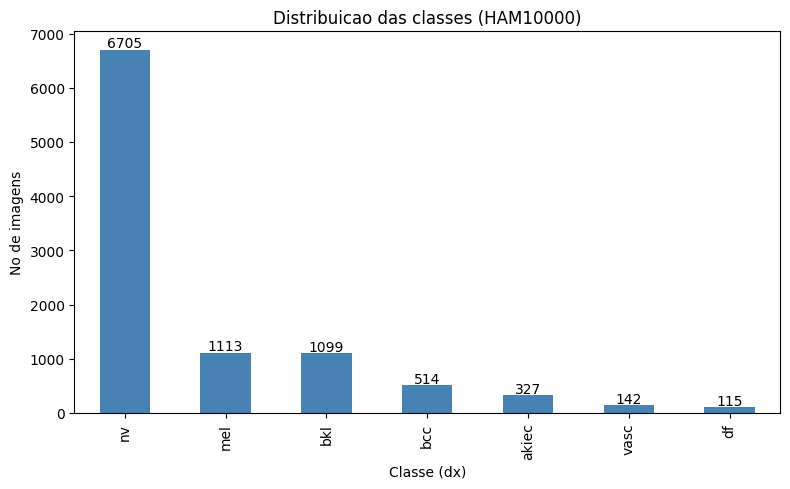


Classe majoritaria: nv (66.9%)
Classe minoritaria: df (1.1%)
Razao maj/min: 58.3x


In [ ]:
class_names = {
    'nv': 'Nevo melanocitico',
    'mel': 'Melanoma',
    'bkl': 'Ceratose benigna (tipo)',
    'bcc': 'Carcinoma basocelular',
    'akiec': 'Ceratose actinica / Bowen',
    'vasc': 'Lesao vascular',
    'df': 'Dermatofibroma',
}

counts = df['dx'].value_counts()
perc = (counts / counts.sum() * 100).round(1)
dist = pd.DataFrame({'contagem': counts, 'percentual (%)': perc})
print(dist)

ax = counts.plot(kind='bar', color='steelblue')
ax.set_title('Distribuicao das classes (HAM10000)')
ax.set_xlabel('Classe (dx)'); ax.set_ylabel('No de imagens')
for i, v in enumerate(counts.values):
    ax.text(i, v + 40, str(v), ha='center')
plt.tight_layout(); plt.show()

print(f"\nClasse majoritaria: {counts.idxmax()} ({perc.max()}%)")
print(f"Classe minoritaria: {counts.idxmin()} ({perc.min()}%)")
print(f"Razao maj/min: {counts.max()/counts.min():.1f}x")

## 3. `lesion_id` duplicados — risco de vazamento de dados

O HAM10000 tem **várias imagens da mesma lesão física**. Se o split for por imagem,
a mesma lesão pode cair em treino e teste ao mesmo tempo → métricas infladas.
Por isso o split tem que ser **agrupado por `lesion_id`**.

Imagens por lesao - estatisticas:
count    7470.000000
mean        1.340696
std         0.633970
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max         6.000000
dtype: float64

Lesoes com mais de 1 imagem: 1956 de 7470 (26.2%)


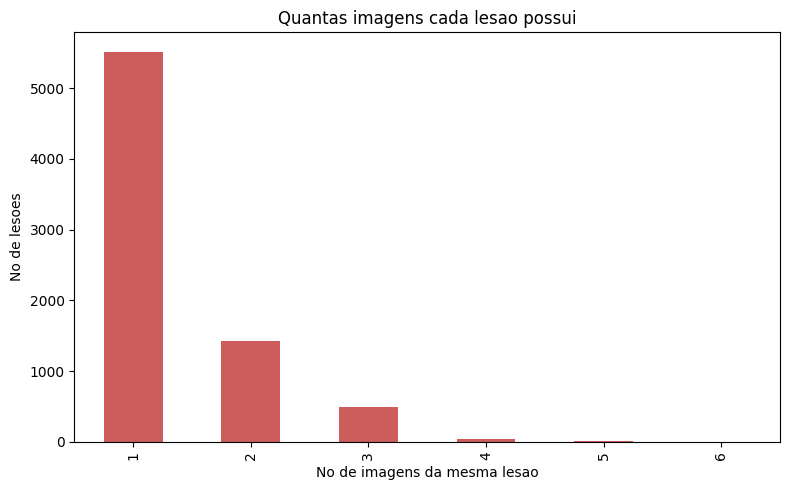

In [ ]:
img_per_lesion = df.groupby('lesion_id').size()
print('Imagens por lesao - estatisticas:')
print(img_per_lesion.describe())
n_multi = (img_per_lesion > 1).sum()
print(f"\nLesoes com mais de 1 imagem: {n_multi} de {img_per_lesion.shape[0]} "
      f"({(img_per_lesion > 1).mean()*100:.1f}%)")

img_per_lesion.value_counts().sort_index().plot(kind='bar', color='indianred')
plt.title('Quantas imagens cada lesao possui')
plt.xlabel('No de imagens da mesma lesao'); plt.ylabel('No de lesoes')
plt.tight_layout(); plt.show()

## 4. Metadados: idade, sexo, localização, tipo de diagnóstico

In [ ]:
print('Valores ausentes por coluna:')
print(df.isnull().sum())

print('\nSexo:'); print(df['sex'].value_counts(dropna=False))
print('\nTipo de diagnostico (dx_type):'); print(df['dx_type'].value_counts())
print('\nLocalizacao (top 10):'); print(df['localization'].value_counts().head(10))

Valores ausentes por coluna:
lesion_id        0
image_id         0
dx               0
dx_type          0
age             57
sex              0
localization     0
dtype: int64

Sexo:
sex
male       5406
female     4552
unknown      57
Name: count, dtype: int64

Tipo de diagnostico (dx_type):
dx_type
histo        5340
follow_up    3704
consensus     902
confocal       69
Name: count, dtype: int64

Localizacao (top 10):
localization
back               2192
lower extremity    2077
trunk              1404
upper extremity    1118
abdomen            1022
face                745
chest               407
foot                319
unknown             234
neck                168
Name: count, dtype: int64


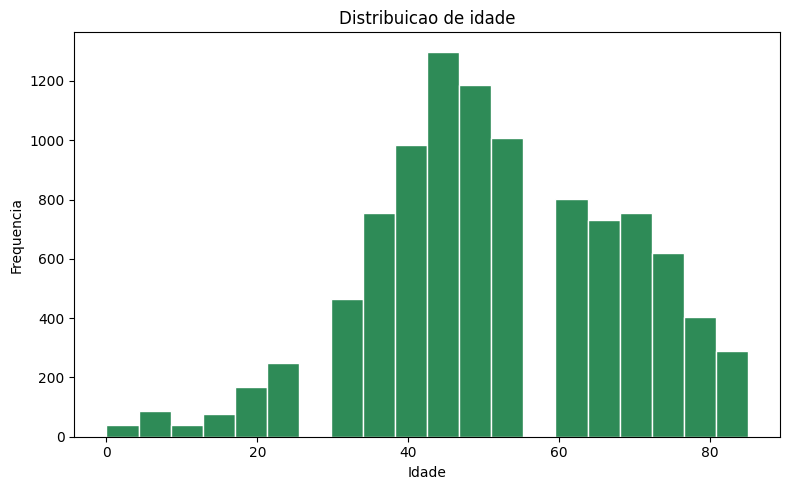

Idade - describe:
count    9958.000000
mean       51.863828
std        16.968614
min         0.000000
25%        40.000000
50%        50.000000
75%        65.000000
max        85.000000
Name: age, dtype: float64
Idades ausentes: 57


In [ ]:
df['age'].plot(kind='hist', bins=20, color='seagreen', edgecolor='white')
plt.title('Distribuicao de idade'); plt.xlabel('Idade'); plt.ylabel('Frequencia')
plt.tight_layout(); plt.show()
print('Idade - describe:'); print(df['age'].describe())
print('Idades ausentes:', df['age'].isnull().sum())

## 5. Amostras de imagens por classe

In [ ]:
# Mapeia image_id -> caminho do arquivo, varrendo as pastas de imagens
img_paths = {}
for root, _, files in os.walk(DATA_DIR):
    for f in files:
        if f.lower().endswith('.jpg'):
            img_paths[os.path.splitext(f)[0]] = os.path.join(root, f)
print('Imagens .jpg encontradas:', len(img_paths))

Imagens .jpg encontradas: 10015


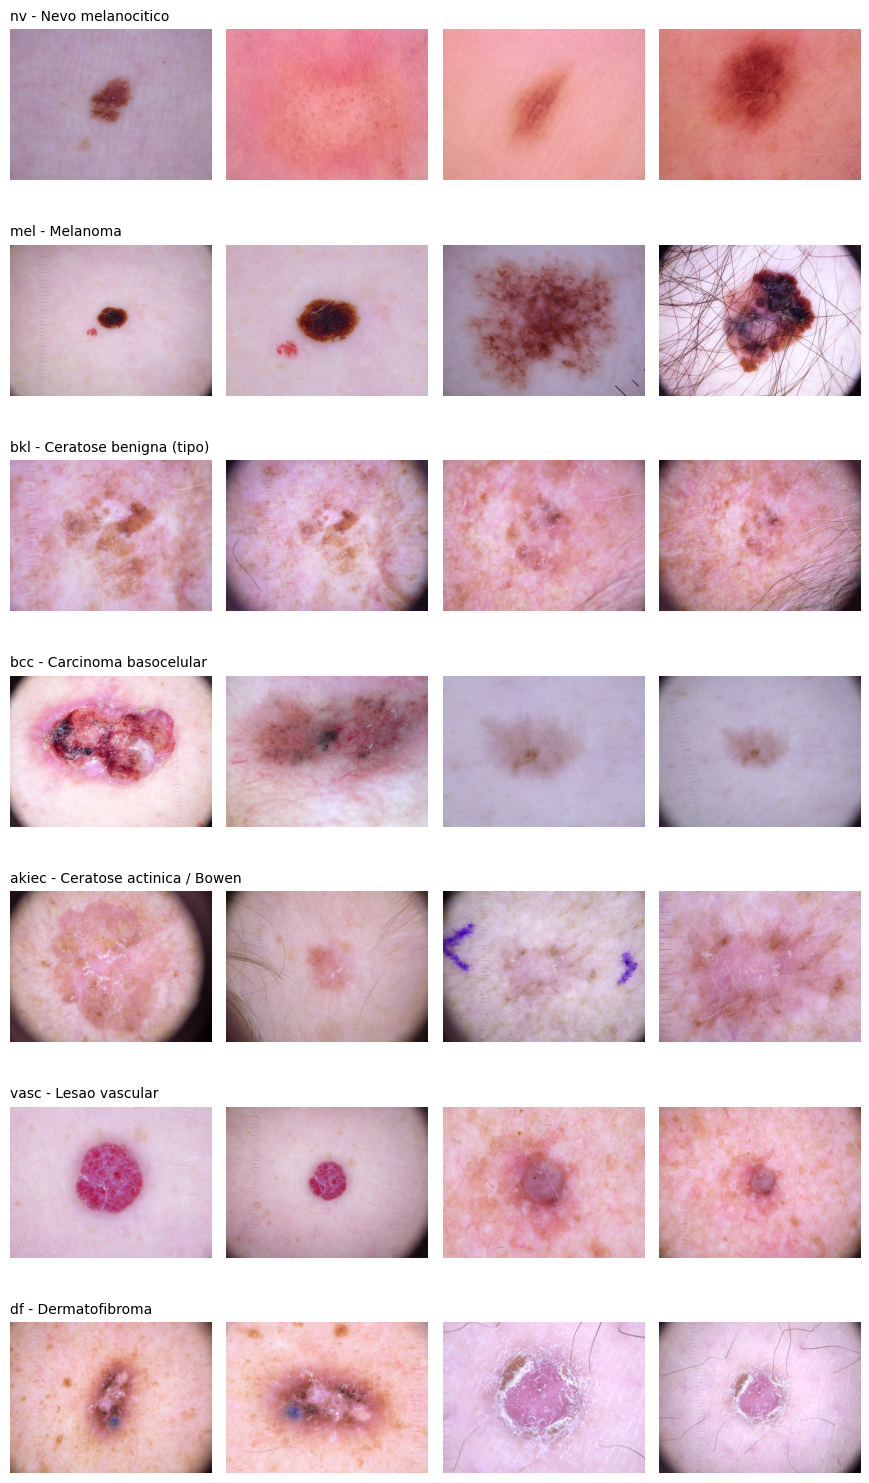

In [ ]:
n_per_class = 4
classes = list(class_names.keys())
fig, axes = plt.subplots(len(classes), n_per_class,
                         figsize=(n_per_class*2.2, len(classes)*2.2))
for r, c in enumerate(classes):
    sample_ids = df[df['dx'] == c]['image_id'].head(n_per_class).tolist()
    for k in range(n_per_class):
        ax = axes[r, k]; ax.axis('off')
        if k < len(sample_ids) and sample_ids[k] in img_paths:
            ax.imshow(Image.open(img_paths[sample_ids[k]]))
        if k == 0:
            ax.set_title(f"{c} - {class_names[c]}", loc='left', fontsize=10)
plt.tight_layout(); plt.show()

In [ ]:
# Checagem de dimensoes em uma amostra
sample_paths = list(img_paths.values())[:50]
sizes = [Image.open(p).size for p in sample_paths]
print('Tamanhos unicos na amostra:', set(sizes))

Tamanhos unicos na amostra: {(600, 450)}
